In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

def plot_error_figs(file_name, prefix):

    # 1. Load the JSON file
    file_path = f'../results/{file_name}'
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Accumulators
    dynamic_ensemble = {'y_true': [], 'y_pred': []}
    model_accumulators = {}

    # 2. Extract and Aggregate Data
    for sem_idx, sem_data in data['dynamic_k'].items():
        dynamic_ensemble['y_true'].extend(sem_data['y_true'])
        dynamic_ensemble['y_pred'].extend(sem_data['y_pred'])

        if 'y_preds' in sem_data:
            for model_name, model_preds in sem_data['y_preds'].items():
                if model_name not in model_accumulators:
                    model_accumulators[model_name] = {'y_true': [], 'y_pred': []}
                model_accumulators[model_name]['y_true'].extend(model_preds['y_true'])
                model_accumulators[model_name]['y_pred'].extend(model_preds['y_pred'])

    results = []

    # 3. Calculate Adaptive Ensemble Metrics
    y_true_ens = np.array(dynamic_ensemble['y_true'])
    y_pred_ens = np.array(dynamic_ensemble['y_pred'])

    # Clean ensemble data (filter out Nones/NaNs/Infs)
    mask_ens = np.array([p is not None for p in y_pred_ens])
    y_true_ens = y_true_ens[mask_ens]
    y_pred_ens = y_pred_ens[mask_ens]

    mask_ens2 = ~np.isnan(y_pred_ens) & ~np.isinf(y_pred_ens)
    y_true_ens = y_true_ens[mask_ens2]
    y_pred_ens = y_pred_ens[mask_ens2]

    ens_rmse = np.sqrt(mean_squared_error(y_true_ens, y_pred_ens))
    ens_mae = mean_absolute_error(y_true_ens, y_pred_ens)
    ens_hem = (2 * ens_rmse * ens_mae) / (ens_rmse + ens_mae + 1e-8)  # Calculate Global HEM

    results.append({'Model': 'Adaptive Ensemble k1', 'RMSE': ens_rmse, 'MAE': ens_mae, 'HEM': ens_hem})

    # 4. Calculate Individual Global Metrics
    for model_name, acc in model_accumulators.items():
        if len(acc['y_true']) > 0:
            y_t_arr = np.array(acc['y_true'])
            y_p_arr = np.array(acc['y_pred'])

            # Filter out Nones/NaNs/Infs
            mask1 = np.array([p is not None for p in y_p_arr])
            y_t_arr = y_t_arr[mask1]
            y_p_arr = y_p_arr[mask1]

            mask2 = ~np.isnan(y_p_arr) & ~np.isinf(y_p_arr)
            y_t_arr = y_t_arr[mask2]
            y_p_arr = y_p_arr[mask2]

            if len(y_t_arr) > 0:
                rmse = np.sqrt(mean_squared_error(y_t_arr, y_p_arr))
                mae = mean_absolute_error(y_t_arr, y_p_arr)
                hem = (2 * rmse * mae) / (rmse + mae + 1e-8)  # Calculate Individual HEM
                results.append({'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'HEM': hem})

    df = pd.DataFrame(results)

    # Print Proof
    print("=== FINAL MODEL RANKINGS (CompSem Temporal Holdout) ===")
    print(df.sort_values(by='RMSE', ascending=True).to_string(index=False))


    # ==========================================
    # 5. Plotting RMSE
    # ==========================================
    df_rmse = df.sort_values(by='RMSE', ascending=True)

    plt.figure(figsize=(12, 6))
    ax_rmse = sns.barplot(data=df_rmse, x='Model', y='RMSE', hue='Model', palette='viridis', order=df_rmse['Model'], legend=False)

    for i, bar in enumerate(ax_rmse.patches):
        if df_rmse.iloc[i]['Model'] == 'Adaptive Ensemble k1':
            bar.set_color('crimson')

    plt.ylabel('RMSE', fontsize=14)
    plt.xlabel('Candidate Model', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, df_rmse['RMSE'].max() * 1.1)

    for index, value in enumerate(df_rmse['RMSE']):
        plt.text(index, value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'../visualizations/{prefix}_AllModels_RMSE.pdf', format='pdf', bbox_inches='tight')
    print("Saved RMSE chart as a vector graphic!")


    # ==========================================
    # 6. Plotting MAE
    # ==========================================
    df_mae = df.sort_values(by='MAE', ascending=True)

    plt.figure(figsize=(12, 6))
    ax_mae = sns.barplot(data=df_mae, x='Model', y='MAE', hue='Model', palette='magma', order=df_mae['Model'], legend=False)

    for i, bar in enumerate(ax_mae.patches):
        if df_mae.iloc[i]['Model'] == 'Adaptive Ensemble k1':
            bar.set_color('crimson')

    plt.ylabel('MAE', fontsize=14)
    plt.xlabel('Candidate Model', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, df_mae['MAE'].max() * 1.1)

    for index, value in enumerate(df_mae['MAE']):
        plt.text(index, value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'../visualizations/{prefix}_AllModels_MAE.pdf', format='pdf', bbox_inches='tight')
    print("Saved MAE chart as a vector graphic!")


    # ==========================================
    # 6.5 Plotting HEM
    # ==========================================
    df_hem = df.sort_values(by='HEM', ascending=True)

    plt.figure(figsize=(12, 6))
    # Using 'plasma' palette for visual distinction
    ax_hem = sns.barplot(data=df_hem, x='Model', y='HEM', hue='Model', palette='plasma', order=df_hem['Model'], legend=False)

    for i, bar in enumerate(ax_hem.patches):
        if df_hem.iloc[i]['Model'] == 'Adaptive Ensemble k1':
            bar.set_color('crimson')

    plt.ylabel('HEM (Harmonic Mean)', fontsize=14)
    plt.xlabel('Candidate Model', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, df_hem['HEM'].max() * 1.1)

    for index, value in enumerate(df_hem['HEM']):
        plt.text(index, value + 0.01, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'../visualizations/{prefix}_AllModels_HEM.pdf', format='pdf', bbox_inches='tight')
    print("Saved HEM chart as a vector graphic!")


    # ==========================================
    # 7. Calculate Per-Semester Trajectories
    # ==========================================
    sem_rmse_results = []
    sem_mae_results = []
    sem_hem_results = []

    for sem_idx in sorted(data['dynamic_k'].keys(), key=int):
        sem_data = data['dynamic_k'][sem_idx]

        row_rmse = {'Semester': int(sem_idx)}
        row_mae = {'Semester': int(sem_idx)}
        row_hem = {'Semester': int(sem_idx)}

        # Process Adaptive Ensemble
        y_true_ens = np.array(sem_data['y_true'])
        y_pred_ens = np.array(sem_data['y_pred'])

        mask_ens = np.array([p is not None for p in y_pred_ens])
        y_true_ens, y_pred_ens = y_true_ens[mask_ens], y_pred_ens[mask_ens]

        mask_ens2 = ~np.isnan(y_pred_ens) & ~np.isinf(y_pred_ens)
        y_true_ens, y_pred_ens = y_true_ens[mask_ens2], y_pred_ens[mask_ens2]

        if len(y_true_ens) > 0:
            rmse_val = np.sqrt(mean_squared_error(y_true_ens, y_pred_ens))
            mae_val = mean_absolute_error(y_true_ens, y_pred_ens)

            row_rmse['Adaptive Ensemble k1'] = rmse_val
            row_mae['Adaptive Ensemble k1'] = mae_val
            row_hem['Adaptive Ensemble k1'] = (2 * rmse_val * mae_val) / (rmse_val + mae_val + 1e-8)
        else:
            row_rmse['Adaptive Ensemble k1'] = np.nan
            row_mae['Adaptive Ensemble k1'] = np.nan
            row_hem['Adaptive Ensemble k1'] = np.nan

        # Process Individual Models
        if 'y_preds' in sem_data:
            for model_name, model_preds in sem_data['y_preds'].items():
                y_t = np.array(model_preds['y_true'])
                y_p = np.array(model_preds['y_pred'])

                mask1 = np.array([p is not None for p in y_p])
                y_t, y_p = y_t[mask1], y_p[mask1]

                mask2 = ~np.isnan(y_p) & ~np.isinf(y_p)
                y_t, y_p = y_t[mask2], y_p[mask2]

                if len(y_t) > 0:
                    m_rmse = np.sqrt(mean_squared_error(y_t, y_p))
                    m_mae = mean_absolute_error(y_t, y_p)

                    row_rmse[model_name] = m_rmse
                    row_mae[model_name] = m_mae
                    row_hem[model_name] = (2 * m_rmse * m_mae) / (m_rmse + m_mae + 1e-8)
                else:
                    row_rmse[model_name] = np.nan
                    row_mae[model_name] = np.nan
                    row_hem[model_name] = np.nan

        sem_rmse_results.append(row_rmse)
        sem_mae_results.append(row_mae)
        sem_hem_results.append(row_hem)

    df_sem_rmse = pd.DataFrame(sem_rmse_results).set_index('Semester')
    df_sem_mae = pd.DataFrame(sem_mae_results).set_index('Semester')
    df_sem_hem = pd.DataFrame(sem_hem_results).set_index('Semester')


    # ==========================================
    # 8. Plotting Semester Trajectories (Line Charts)
    # ==========================================

    def plot_trajectories(df_traj, metric_name, filename):
        plt.figure(figsize=(14, 8))

        for col in df_traj.columns:
            if col == 'Adaptive Ensemble k1':
                plt.plot(df_traj.index, df_traj[col], label=col, color='crimson', linewidth=4, marker='D', markersize=8, zorder=10)
            elif col in ['MLP', 'SVR', 'Ridge', 'LR', 'BayesianRidge']:
                plt.plot(df_traj.index, df_traj[col], label=col, linewidth=2.5, linestyle='--', marker='o')
            elif col != 'CF':
                plt.plot(df_traj.index, df_traj[col], label=col, linewidth=1.5, alpha=0.5)

        plt.xlabel('Semester Index', fontsize=14)
        plt.ylabel(f'Test {metric_name}', fontsize=14)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.savefig(filename, format='pdf', bbox_inches='tight')
        print(f"Saved {metric_name} trajectory chart to {filename}")

    # Generate all 3 Line Charts
    plot_trajectories(df_sem_rmse, 'RMSE', f'../visualizations/{prefix}_Trajectories_RMSE.pdf')
    plot_trajectories(df_sem_mae, 'MAE', f'../visualizations/{prefix}_Trajectories_MAE.pdf')
    plot_trajectories(df_sem_hem, 'HEM', f'../visualizations/{prefix}_Trajectories_HEM.pdf')

No-clustering Figures

=== FINAL MODEL RANKINGS (CompSem Temporal Holdout) ===
               Model     RMSE      MAE      HEM
Adaptive Ensemble k1 0.596130 0.423770 0.495386
                 GBM 0.596130 0.423770 0.495386
             Bagging 0.608197 0.429126 0.503205
                  RF 0.644355 0.488669 0.555816
                 SVR 0.645936 0.456991 0.535279
               Ridge 0.654453 0.487462 0.558747
                 KNN 0.735223 0.530937 0.616600
                 MLP 0.735638 0.523587 0.611758
               Lasso 0.822323 0.661328 0.733090
                  CF 1.131308 0.888629 0.995391
Saved RMSE chart as a vector graphic!
Saved MAE chart as a vector graphic!
Saved HEM chart as a vector graphic!
Saved RMSE trajectory chart to ../visualizations/course_based_k1_Trajectories_RMSE.pdf
Saved MAE trajectory chart to ../visualizations/course_based_k1_Trajectories_MAE.pdf
Saved HEM trajectory chart to ../visualizations/course_based_k1_Trajectories_HEM.pdf


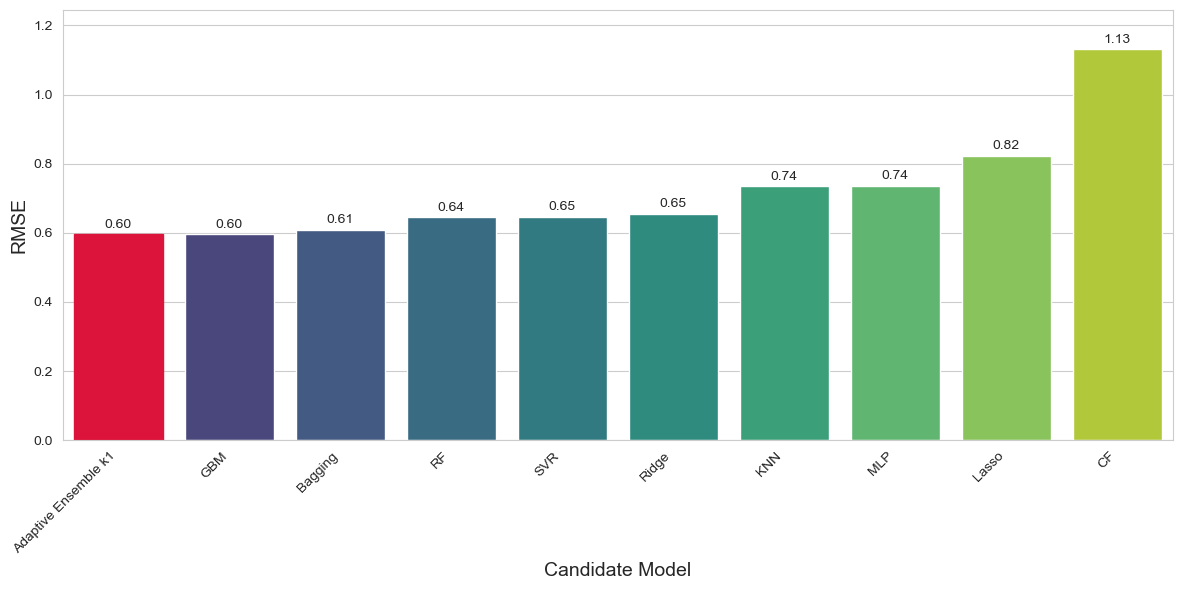

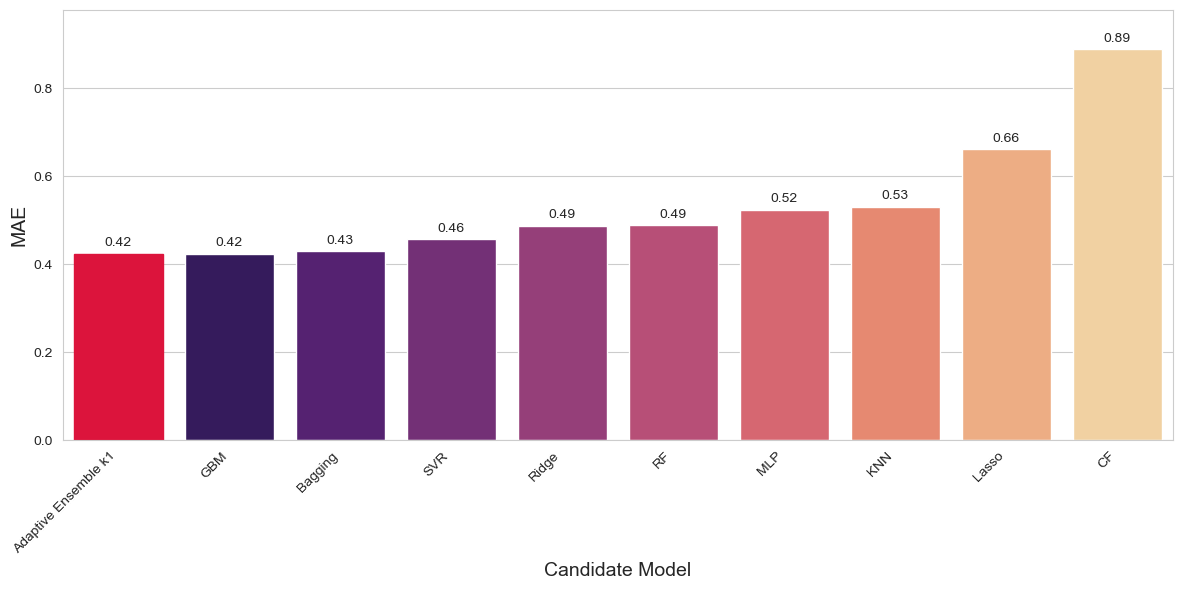

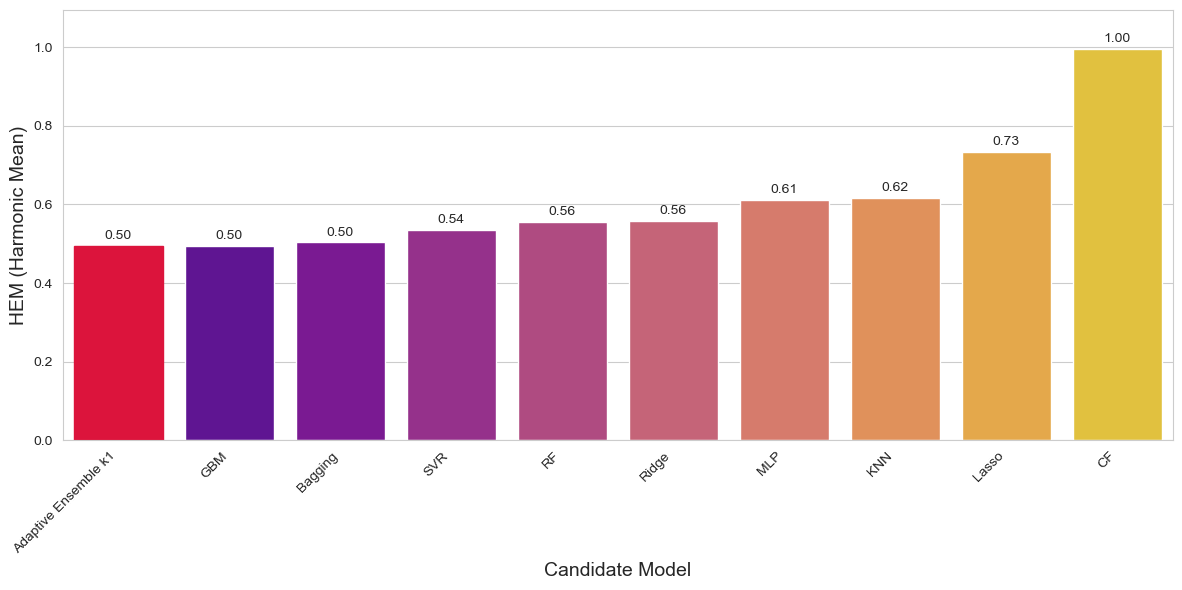

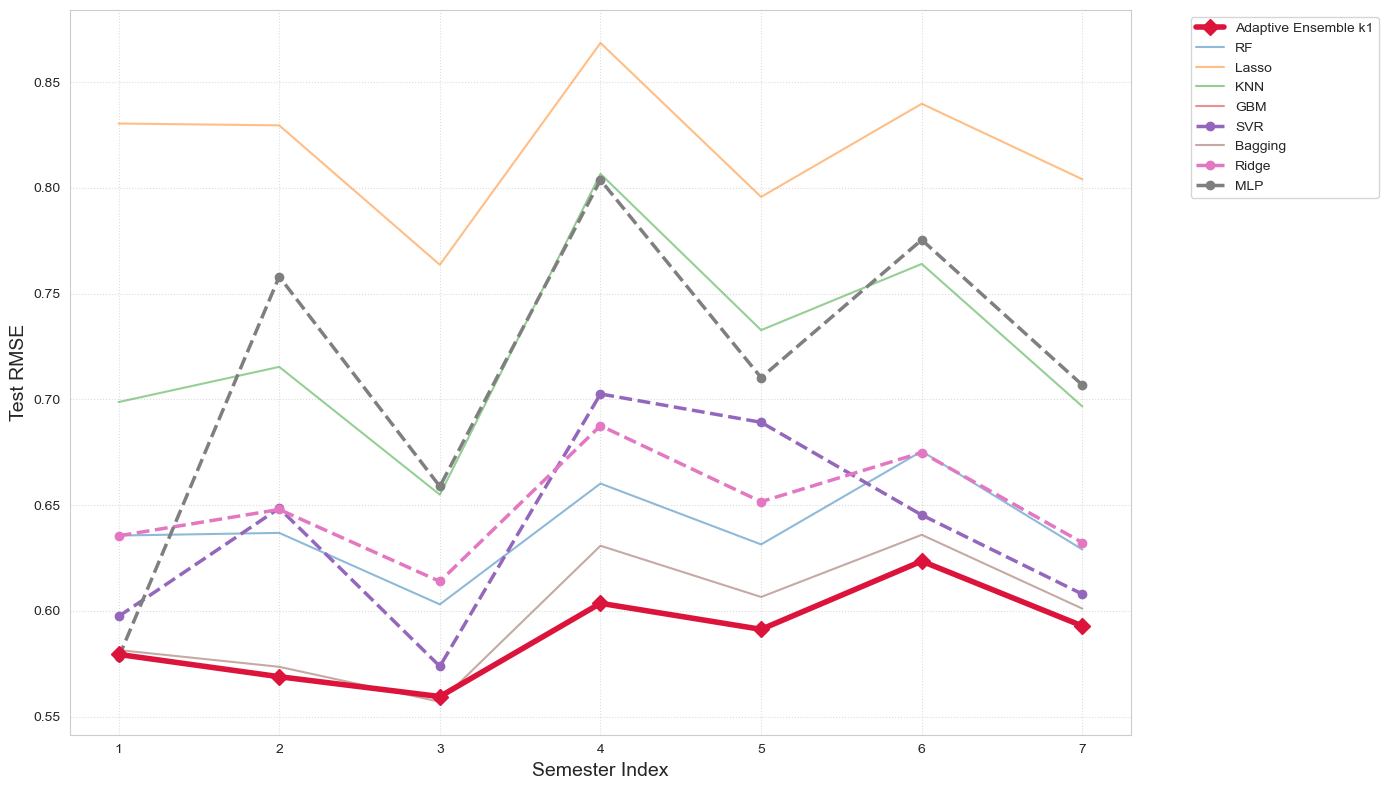

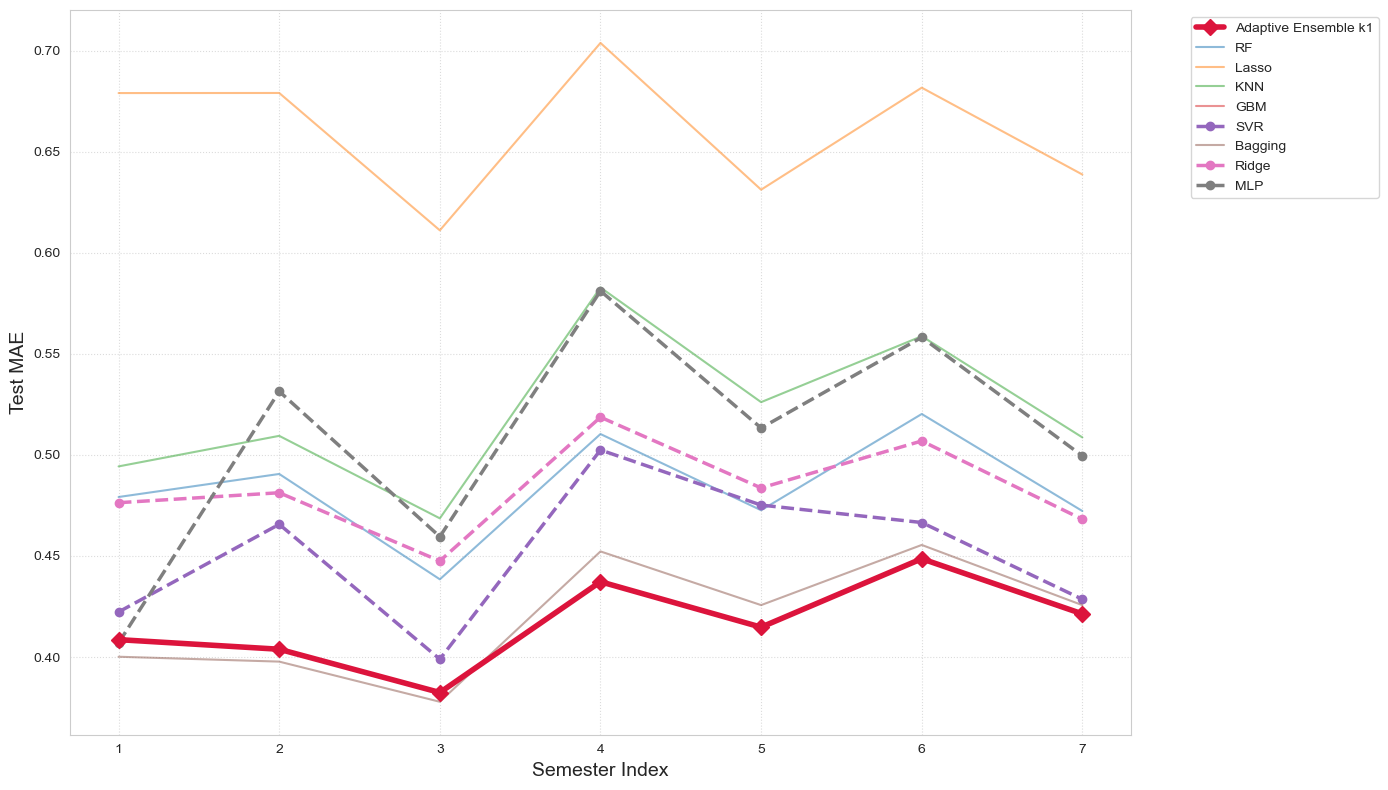

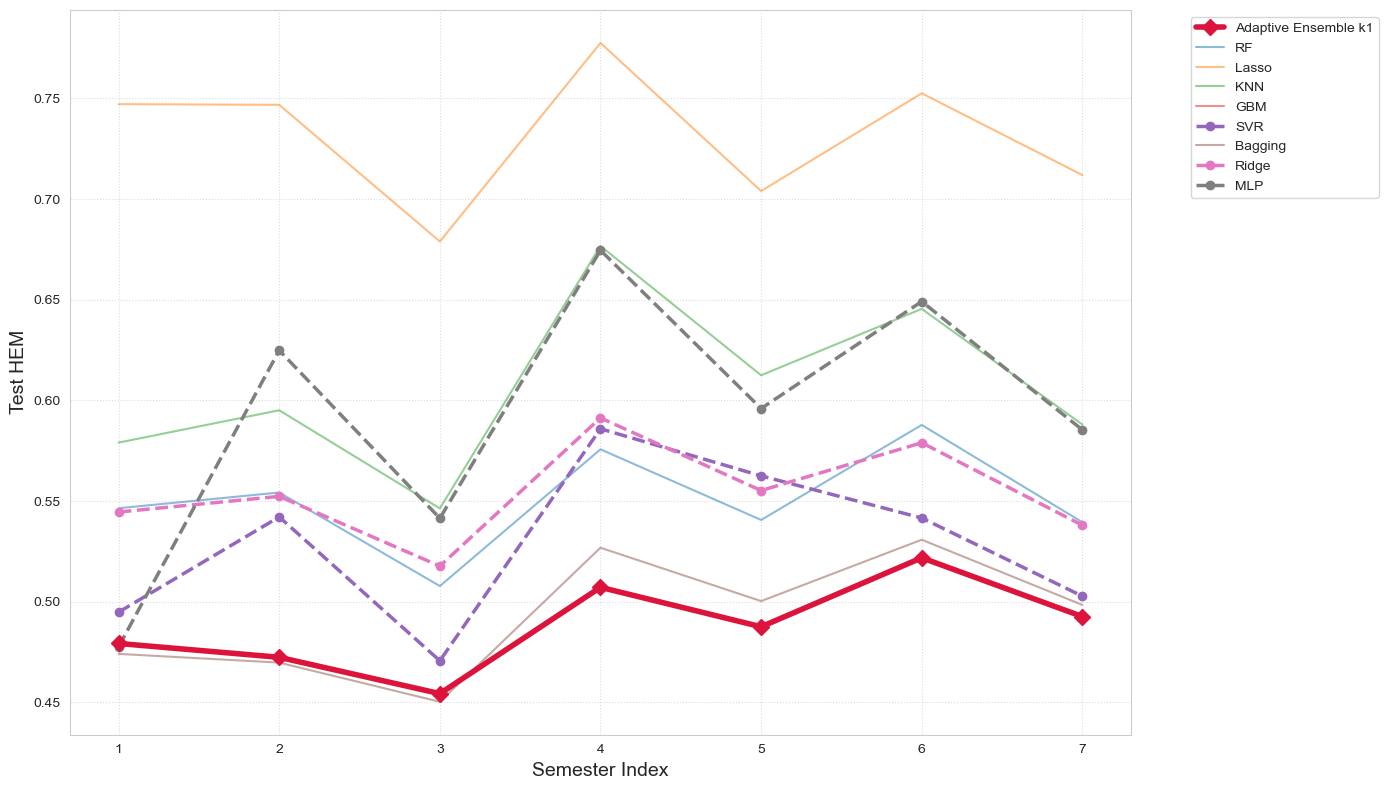

In [4]:
plot_error_figs('adaptive_regression_results_course_based_KMeans.k1.ALL.NarrowFit.RMSE.json', 'course_based_k1')

=== FINAL MODEL RANKINGS (CompSem Temporal Holdout) ===
               Model     RMSE      MAE      HEM
Adaptive Ensemble k1 0.570916 0.412324 0.478830
             Bagging 0.570916 0.412324 0.478830
                 SVR 0.634251 0.465122 0.536677
                 MLP 0.639529 0.474901 0.545055
                  RF 0.669659 0.533917 0.594134
               Ridge 0.683081 0.540304 0.603361
                 KNN 0.726692 0.550769 0.626617
               Lasso 0.814792 0.660327 0.729472
                 GBM 0.919001 0.731146 0.814381
                  CF 1.110083 0.863801 0.971578
Saved RMSE chart as a vector graphic!
Saved MAE chart as a vector graphic!
Saved HEM chart as a vector graphic!
Saved RMSE trajectory chart to ../visualizations/course_based_c300_Trajectories_RMSE.pdf
Saved MAE trajectory chart to ../visualizations/course_based_c300_Trajectories_MAE.pdf
Saved HEM trajectory chart to ../visualizations/course_based_c300_Trajectories_HEM.pdf


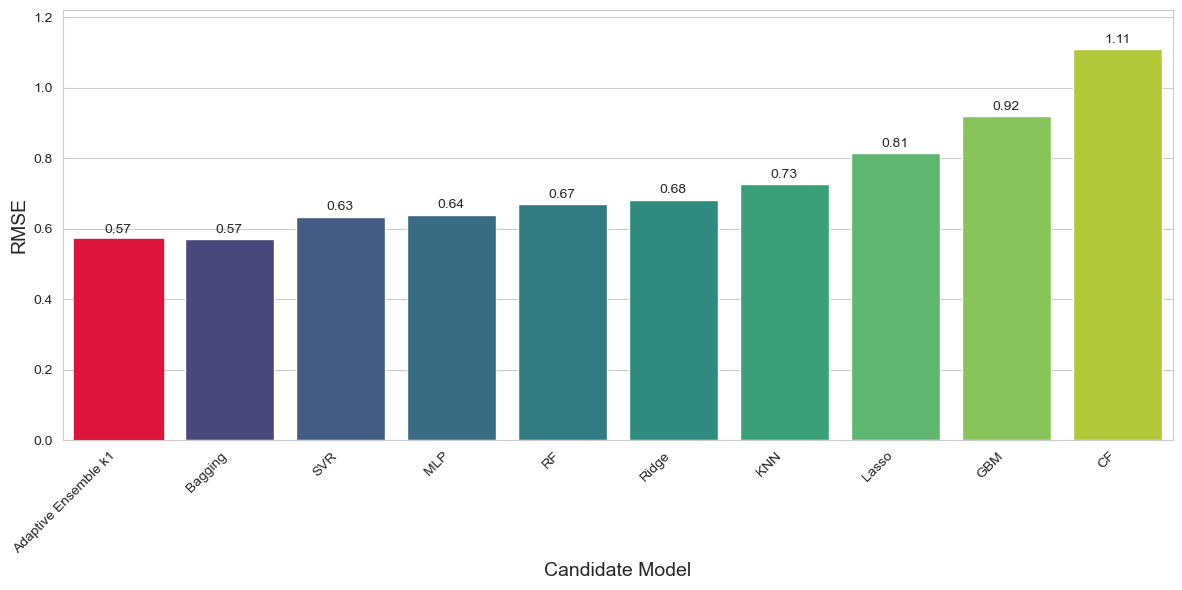

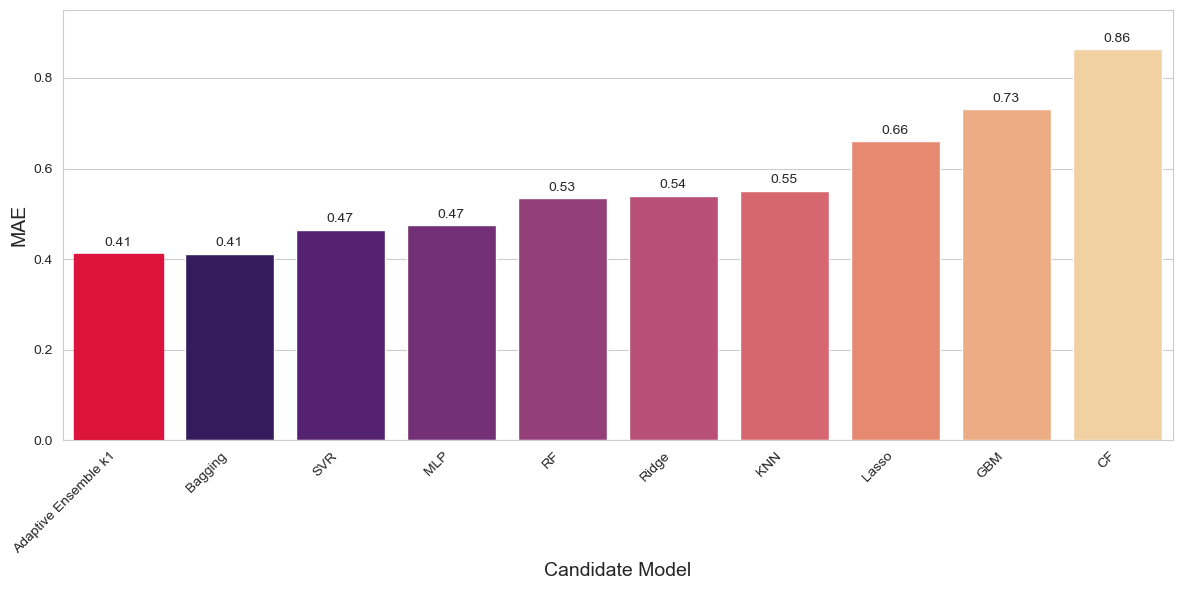

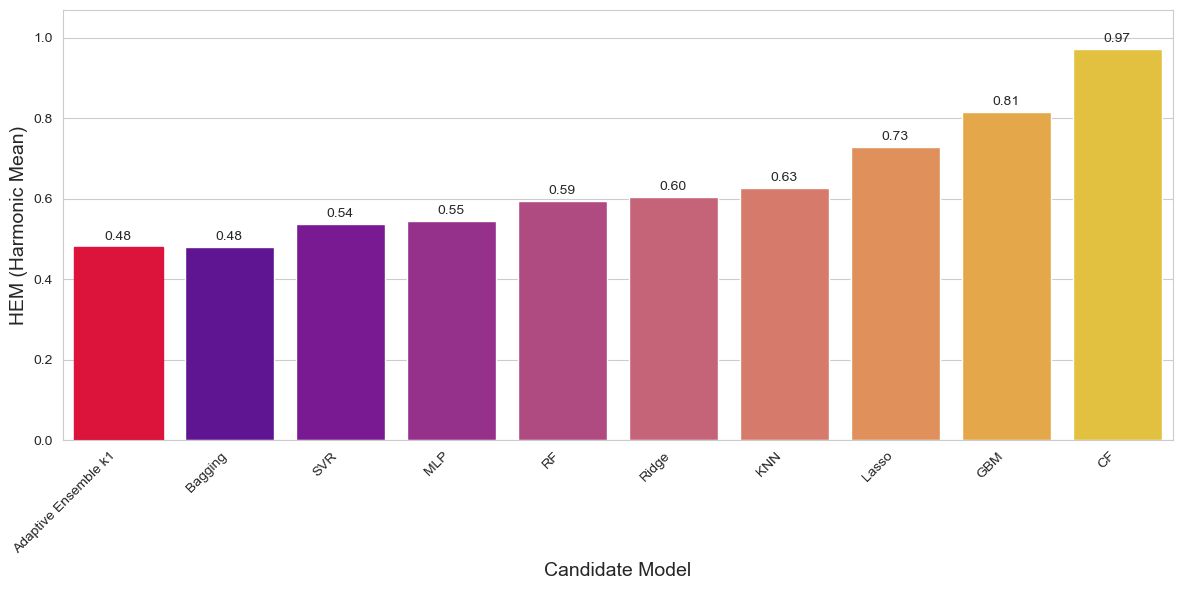

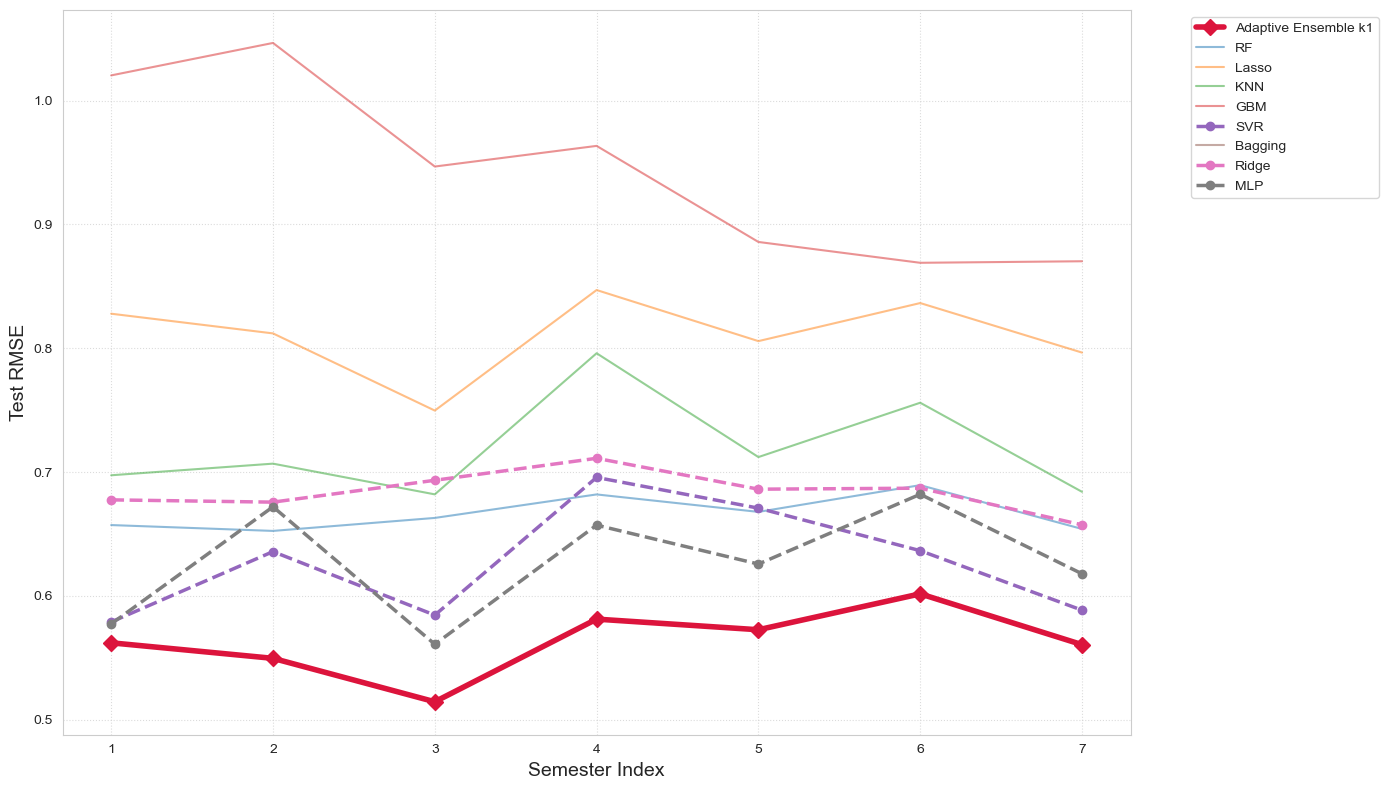

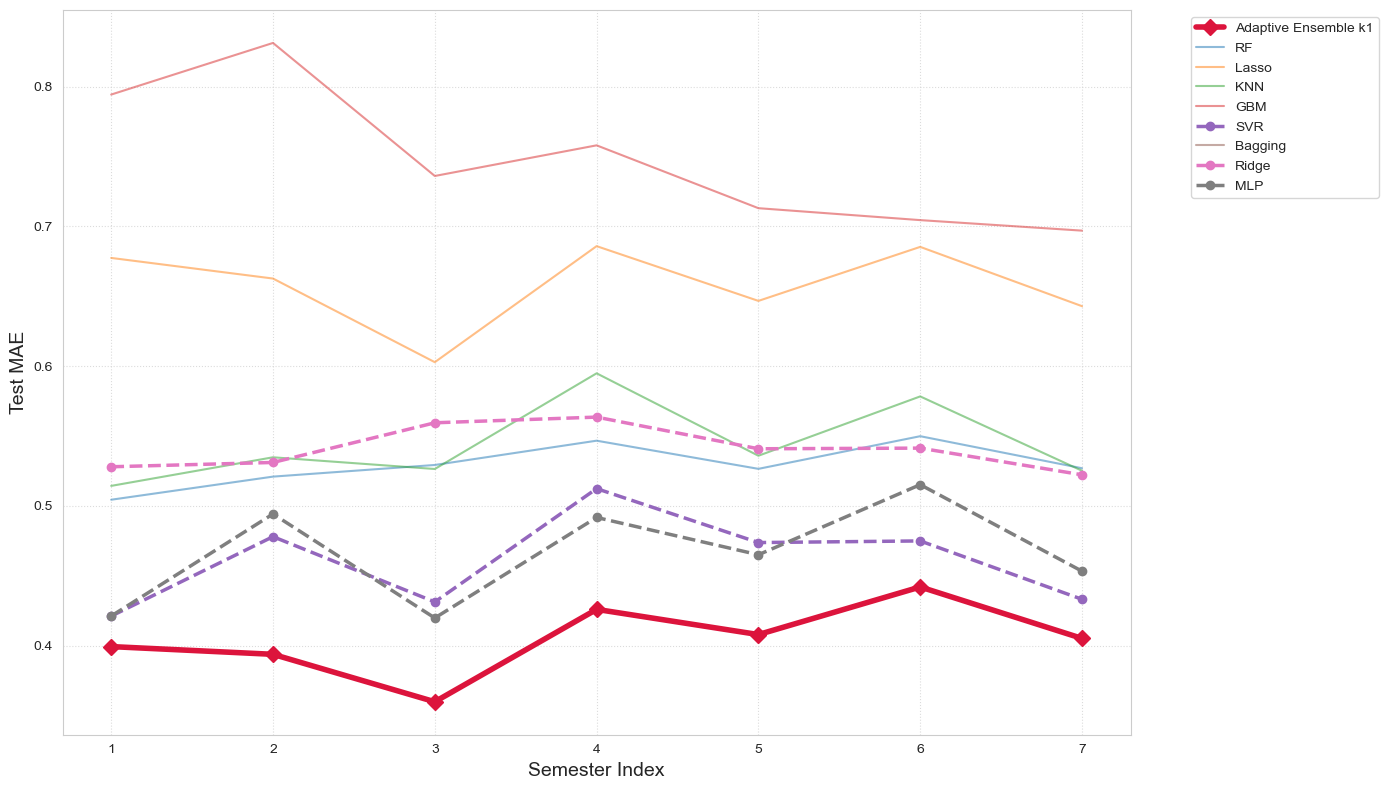

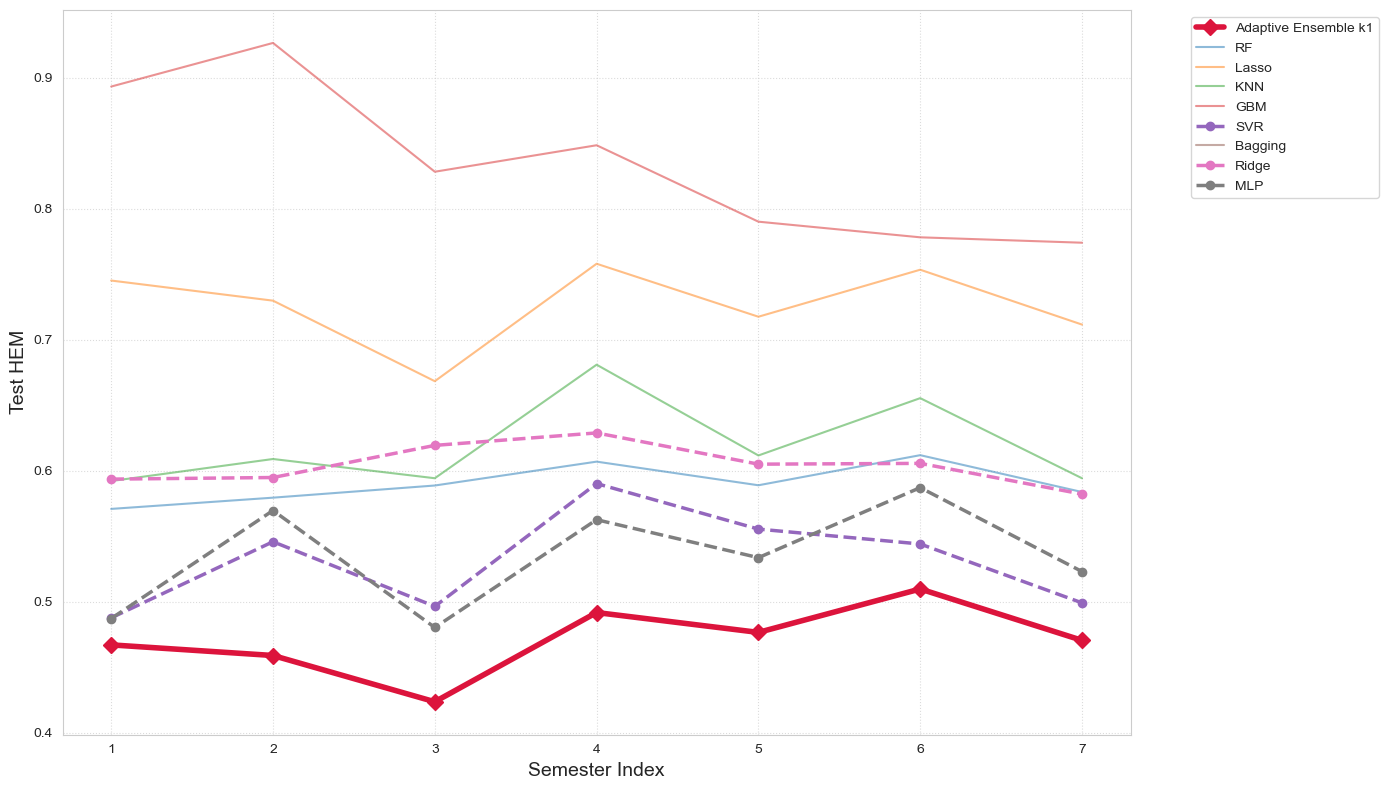

In [5]:
plot_error_figs('adaptive_regression_results_course_based_KMeans.c300.ALL.NarrowFit.RMSE.json', 'course_based_c300')

In [19]:
import json
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def generate_latex_table(course_json_path, student_json_path):
    """
    Parses JSON results, calculates the Harmonic Error Mean (HEM),
    extracts the Silhouette scores, and generates a LaTeX table
    with the best results dynamically bolded.
    """

    def extract_metrics(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        y_true_all = []
        y_pred_all = []
        silhouettes = []

        for k_val, content in data.get('dynamic_k', {}).items():
            # 1. Extract Predictions
            y_t = content.get('y_true', [])
            y_p = content.get('y_pred', [])
            y_true_all.extend(y_t)
            y_pred_all.extend(y_p)

            # 2. Extract Silhouette Scores (Now present in your JSON!)
            # First check for overall semester silhouette
            if 'sil_score' in content and content['sil_score'] is not None:
                silhouettes.append(content['sil_score'])
            # Fallback to averaging the cluster_silhouette dictionary if needed
            elif 'cluster_silhouette' in content and isinstance(content['cluster_silhouette'], dict):
                valid_sils = [v for v in content['cluster_silhouette'].values() if v is not None]
                if valid_sils:
                    silhouettes.append(np.mean(valid_sils))

        # 3. Clean arrays (remove NaNs or Infs that might crash metrics)
        y_t_arr = np.array(y_true_all, dtype=float)
        y_p_arr = np.array(y_pred_all, dtype=float)
        mask = ~np.isnan(y_p_arr) & ~np.isinf(y_p_arr) & ~np.isnan(y_t_arr) & ~np.isinf(y_t_arr)

        y_t_clean = y_t_arr[mask]
        y_p_clean = y_p_arr[mask]

        if len(y_t_clean) == 0:
            return np.nan, np.nan, np.nan, np.nan

        # 4. Calculate Primary Metrics
        rmse = np.sqrt(mean_squared_error(y_t_clean, y_p_clean))
        mae = mean_absolute_error(y_t_clean, y_p_clean)

        # Calculate HEM (Harmonic Mean of RMSE and MAE)
        hem = (2 * rmse * mae) / (rmse + mae) if (rmse + mae) > 0 else np.nan

        # Average Silhouette across all test semesters
        avg_sil = np.mean(silhouettes) if silhouettes else np.nan

        return rmse, mae, hem, avg_sil

    # Helper function to format strings and apply LaTeX bolding
    def format_comparison(val_c, val_s, lower_is_better=True):
        if np.isnan(val_c) or np.isnan(val_s):
            str_c = f"{val_c:.3f}" if not np.isnan(val_c) else "N/A"
            str_s = f"{val_s:.3f}" if not np.isnan(val_s) else "N/A"
            return str_c, str_s

        # Round to 3 decimals for the comparison to avoid micro-differences
        vc_rnd = round(val_c, 3)
        vs_rnd = round(val_s, 3)

        str_c, str_s = f"{val_c:.3f}", f"{val_s:.3f}"

        # If they are exactly the same, bold both
        if vc_rnd == vs_rnd:
            return f"\\textbf{{{str_c}}}", f"\\textbf{{{str_s}}}"

        # Determine winner based on whether lower or higher is better
        if lower_is_better:
            if vc_rnd < vs_rnd:
                return f"\\textbf{{{str_c}}}", str_s
            else:
                return str_c, f"\\textbf{{{str_s}}}"
        else: # Higher is better (e.g., for Silhouette)
            if vc_rnd > vs_rnd:
                return f"\\textbf{{{str_c}}}", str_s
            else:
                return str_c, f"\\textbf{{{str_s}}}"

    # --- Execution ---
    # Extract metrics for both approaches
    c_rmse, c_mae, c_hem, c_sil = extract_metrics(course_json_path)
    s_rmse, s_mae, s_hem, s_sil = extract_metrics(student_json_path)

    # Format and apply bolding logic
    c_rmse_str, s_rmse_str = format_comparison(c_rmse, s_rmse, lower_is_better=True)
    c_mae_str, s_mae_str   = format_comparison(c_mae, s_mae, lower_is_better=True)
    c_hem_str, s_hem_str   = format_comparison(c_hem, s_hem, lower_is_better=True)
    c_sil_str, s_sil_str   = format_comparison(c_sil, s_sil, lower_is_better=False) # Silhouette: Higher is better

    # Generate LaTeX String
    latex_code = f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Overall Performance Comparison of Adaptive Clustering Strategies}}
\\label{{tab:adaptive_clustering_comparison}}
\\begin{{tabular}}{{l c c c c}}
\\toprule
\\textbf{{Clustering Strategy}} & \\textbf{{RMSE}} & \\textbf{{MAE}} & \\textbf{{HEM}} & \\textbf{{Avg. Silhouette}} \\\\
\\midrule
Course-based Adaptive & {c_rmse_str} & {c_mae_str} & {c_hem_str} & {c_sil_str} \\\\
Student-based Adaptive & {s_rmse_str} & {s_mae_str} & {s_hem_str} & {s_sil_str} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
    """

    print(latex_code)
    #return latex_code

# Run the function using your newly generated JSON file
generate_latex_table(
    '..\\results\\adaptive_regression_results_course_based_KMeans.c300.NarrowFit.RMSE.json', # Ensure this one also has the new sil_score!
    '..\\results\\adaptive_regression_results_student_based_KMeans.c300.NarrowFit.RMSE.json'
)


\begin{table}[htbp]
\centering
\caption{Overall Performance Comparison of Adaptive Clustering Strategies}
\label{tab:adaptive_clustering_comparison}
\begin{tabular}{l c c c c}
\toprule
\textbf{Clustering Strategy} & \textbf{RMSE} & \textbf{MAE} & \textbf{HEM} & \textbf{Avg. Silhouette} \\
\midrule
Course-based Adaptive & \textbf{0.571} & \textbf{0.412} & \textbf{0.479} & \textbf{0.201} \\
Student-based Adaptive & 0.735 & 0.542 & 0.624 & 0.115 \\
\bottomrule
\end{tabular}
\end{table}
    


C:\Users\Ali Çakmak\AppData\Local\Temp\ipykernel_15400\2706717511.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(semesters, rotation=25, ha='right', fontsize=11)


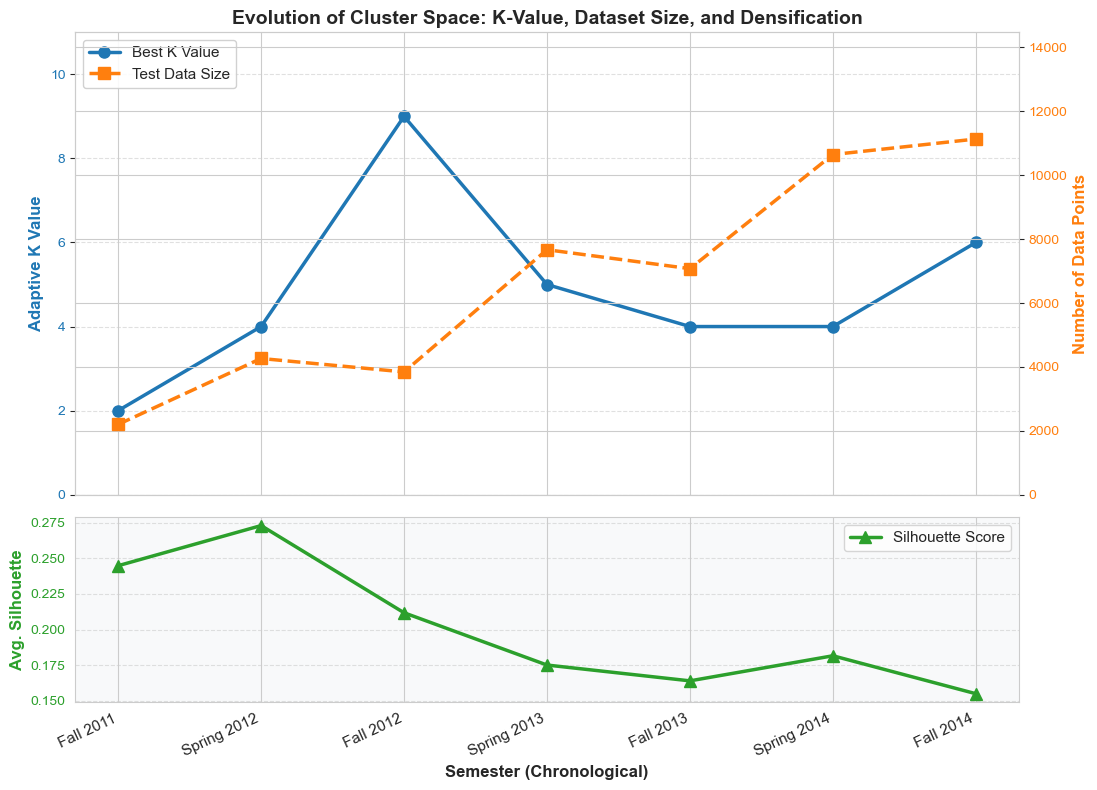

In [20]:
import json
import matplotlib.pyplot as plt

def plot_k_vs_points_vs_silhouette(json_file_path, semester_names=None, output_filename='evolution_of_clusters.png'):
    """
    Generates a 2-panel stacked line chart to display K-Value, Data Points,
    and Silhouette scores across semesters without axis clutter.
    """
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    semesters = []
    k_values = []
    n_points = []
    sil_scores = []

    # Sort chronologically
    sem_keys = sorted(data.get('dynamic_k', {}).keys(), key=int)

    for sem in sem_keys:
        sem_data = data['dynamic_k'][sem]

        # 1. K-Value
        k = sem_data.get('best_k', len(sem_data.get('cv_log', {})))
        # 2. Data Points
        n = len(sem_data.get('y_true', []))
        # 3. Silhouette Score
        sil = sem_data.get('sil_score', np.nan)

        # Labels
        label = semester_names[sem] if (semester_names and sem in semester_names) else f"Sem {sem}"

        semesters.append(label)
        k_values.append(k)
        n_points.append(n)
        sil_scores.append(sil)

    # ==========================================
    # PLOTTING SETUP (2 Rows, 1 Column)
    # height_ratios=[2.5, 1] makes the top panel larger than the bottom
    # ==========================================
    fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

    # --- TOP PANEL: K-value and Data Points ---
    color1 = '#1f77b4' # Muted Blue
    ax1.set_ylabel('Adaptive K Value', color=color1, fontsize=12, fontweight='bold')
    line1 = ax1.plot(semesters, k_values, color=color1, marker='o', linewidth=2.5, markersize=8, label='Best K Value')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_ylim(0, max(k_values) + 2)

    # Twin axis for Data Points
    ax2 = ax1.twinx()
    color2 = '#ff7f0e' # Muted Orange
    ax2.set_ylabel('Number of Data Points', color=color2, fontsize=12, fontweight='bold')
    line2 = ax2.plot(semesters, n_points, color=color2, marker='s', linestyle='--', linewidth=2.5, markersize=8, label='Test Data Size')
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, max(n_points) * 1.3) # Padding for legend

    ax1.set_title('Evolution of Cluster Space: K-Value, Dataset Size, and Densification', fontsize=14, fontweight='bold')

    # Combined Legend for Top Panel
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=11, framealpha=0.9)
    ax1.grid(axis='y', linestyle='--', alpha=0.6)

    # --- BOTTOM PANEL: Silhouette Score ---
    color3 = '#2ca02c' # Muted Green
    ax3.set_xlabel('Semester (Chronological)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Avg. Silhouette', color=color3, fontsize=12, fontweight='bold')

    # Plot Silhouette
    ax3.plot(semesters, sil_scores, color=color3, marker='^', linewidth=2.5, markersize=8, label='Silhouette Score')
    ax3.tick_params(axis='y', labelcolor=color3)

    # Visual separation for the bottom panel
    ax3.set_facecolor('#f8f9fa')
    ax3.grid(axis='y', linestyle='--', alpha=0.6)
    ax3.legend(loc='upper right', fontsize=11)

    # Format X-axis labels
    ax3.set_xticklabels(semesters, rotation=25, ha='right', fontsize=11)

    # Connect and Save
    fig.tight_layout()
    output_file_path = f'..\\visualizations\\{output_filename}'
    plt.savefig(output_file_path, dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# EXECUTION
# ==========================================
semester_mapping = {
    '1': 'Fall 2011', '2': 'Spring 2012', '3': 'Fall 2012',
    '4': 'Spring 2013', '5': 'Fall 2013', '6': 'Spring 2014', '7': 'Fall 2014'
}

plot_k_vs_points_vs_silhouette(
    json_file_path='..\\results\\adaptive_regression_results_course_based_KMeans.c300.NarrowFit.RMSE.json',
    semester_names=semester_mapping
)

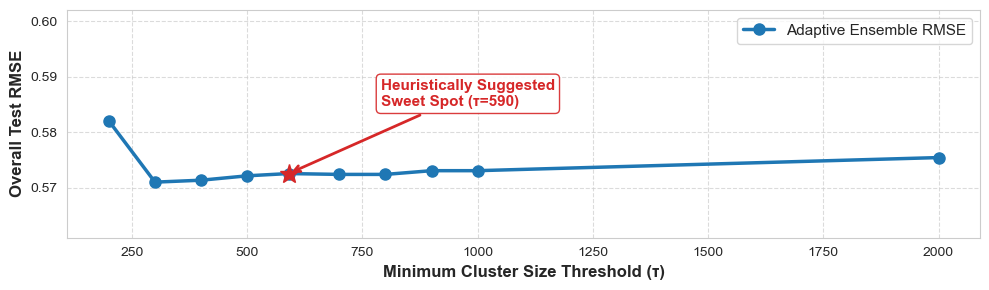

Sweep visualization successfully generated and saved to: ../visualizations\cluster_size_sweep.pdf


In [41]:
import os
import re
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def generate_cluster_sweep_plot(results_dir='../results', viz_dir='../visualizations', output_filename='cluster_size_sweep.pdf'):
    """
    Scans the results directory for minimum cluster size sweep files,
    calculates the overall RMSE for the Adaptive Ensemble, and generates
    a vector graphics (PDF) line chart with the heuristic sweet spot highlighted.
    """

    # Ensure visualization directory exists
    os.makedirs(viz_dir, exist_ok=True)

    # Pattern to match the specific NarrowFit sweep files
    # This will automatically pick up c200, c300... c590... up to c2000
    file_pattern = os.path.join(results_dir, 'adaptive_regression_results_course_based_KMeans.c*.NarrowFit.RMSE.json')
    filepaths = glob.glob(file_pattern)

    if not filepaths:
        print(f"No sweep files found in {results_dir}. Please check the path.")
        return

    sweep_results = {}

    # 1. Parse Files and Calculate Overall RMSE
    for filepath in filepaths:
        # Extract the cluster size (the number right after '.c')
        filename = os.path.basename(filepath)
        match = re.search(r'\.c(\d+)\.NarrowFit', filename)

        if match:
            cluster_size = int(match.group(1))

            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)

            y_true_all = []
            y_pred_all = []

            # Aggregate predictions across all semesters
            for sem, sem_data in data.get('dynamic_k', {}).items():
                y_true_all.extend(sem_data.get('y_true', []))
                y_pred_all.extend(sem_data.get('y_pred', []))

            y_t_arr = np.array(y_true_all, dtype=float)
            y_p_arr = np.array(y_pred_all, dtype=float)

            # Mask NaNs
            mask = ~np.isnan(y_p_arr) & ~np.isinf(y_p_arr) & ~np.isnan(y_t_arr) & ~np.isinf(y_t_arr)

            if np.sum(mask) > 0:
                overall_rmse = np.sqrt(mean_squared_error(y_t_arr[mask], y_p_arr[mask]))
                sweep_results[cluster_size] = overall_rmse

    # 2. Sort the Data
    # Sort by cluster size ascending
    sorted_sizes = sorted(sweep_results.keys())
    sorted_rmses = [sweep_results[size] for size in sorted_sizes]

    # 3. Plotting Setup
    fig, ax = plt.subplots(figsize=(10, 3))

    # Plot the main curve
    color_line = '#1f77b4'
    ax.plot(sorted_sizes, sorted_rmses, marker='o', linestyle='-', linewidth=2.5, markersize=8, color=color_line, label='Adaptive Ensemble RMSE')

    # Styling
    #ax.set_title('Impact of Minimum Cluster Size on Overall Predictive Performance', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Minimum Cluster Size Threshold (\u03C4)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Overall Test RMSE', fontsize=12, fontweight='bold')

    # Grid
    ax.grid(True, linestyle='--', alpha=0.7)

    # 4. Highlight the Heuristic Sweet Spot (590)
    target_size = 590
    if target_size in sweep_results:
        target_rmse = sweep_results[target_size]

        # Plot a special marker for 590
        ax.plot(target_size, target_rmse, marker='*', markersize=14, color='#d62728', zorder=5)

        # Add the annotation arrow
        # The xytext offset moves the text up and slightly to the right to prevent line overlap
        y_offset = (max(sorted_rmses) - min(sorted_rmses)) * 0.15

        ax.annotate(
            'Heuristically Suggested\nSweet Spot (\u03C4=590)',
            xy=(target_size, target_rmse),
            xytext=(target_size + 200, target_rmse + y_offset+0.01),
            arrowprops=dict(facecolor='#d62728', edgecolor='#d62728', arrowstyle='->', lw=2),
            fontsize=11,
            fontweight='bold',
            color='#d62728',
            ha='left',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d62728", alpha=0.9)
        )

    # Adjust axes to ensure markers and annotations aren't clipped
    ax.set_ylim(min(sorted_rmses) - 0.01, max(sorted_rmses) + 0.02)

    # Show legend
    ax.legend(loc='upper right', fontsize=11)

    # 5. Save as Vector Graphics (PDF)
    save_path = os.path.join(viz_dir, output_filename)
    plt.tight_layout()
    plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Sweep visualization successfully generated and saved to: {save_path}")
    #return sweep_results

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Just run the function! It will automatically look in ../results
    # and save the .pdf vector graphic to ../visualizations
    generate_cluster_sweep_plot()

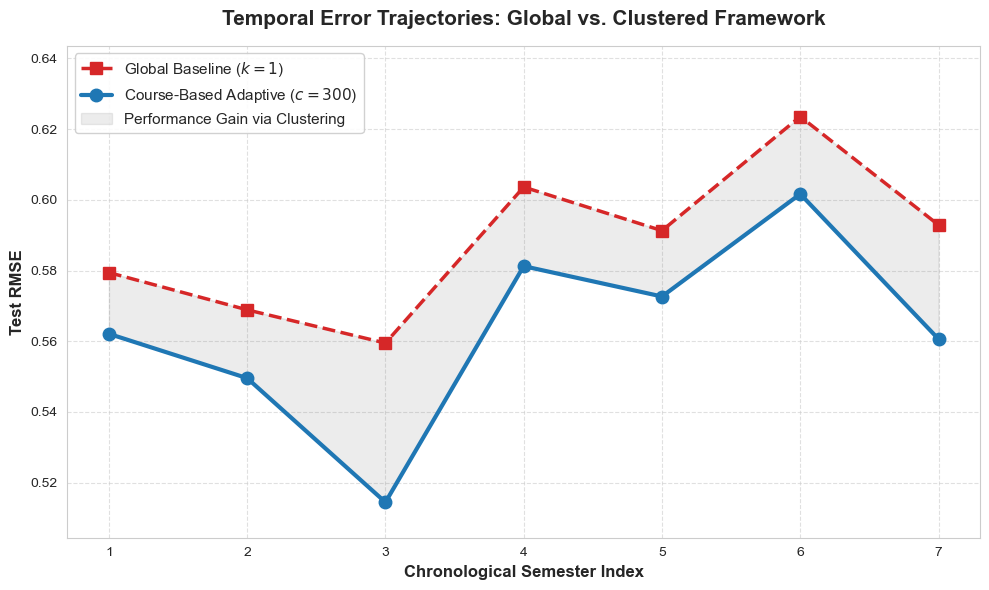

Comparative trajectory plot successfully generated and saved to: ../visualizations\trajectory_k1_vs_c300.pdf


In [45]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def generate_trajectory_comparison_plot(
    k1_json_path='../results/adaptive_regression_results_course_based_KMeans.k1.ALL.NarrowFit.RMSE.json',
    c300_json_path='../results/adaptive_regression_results_course_based_KMeans.c300.ALL.NarrowFit.RMSE.json',
    viz_dir='../visualizations',
    output_filename='trajectory_k1_vs_c300.pdf'
):
    """
    Generates a comparative line chart of RMSE trajectories over time for
    the Global Baseline (k=1) vs. the Course-Based Adaptive Ensemble (c=300).
    """

    # Ensure visualization directory exists
    os.makedirs(viz_dir, exist_ok=True)

    def extract_semester_rmse(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)

        sem_rmses = {}
        # Sort chronologically by semester index
        for sem in sorted(data.get('dynamic_k', {}).keys(), key=int):
            sem_data = data['dynamic_k'][sem]
            y_t = np.array(sem_data.get('y_true', []), dtype=float)
            y_p = np.array(sem_data.get('y_pred', []), dtype=float)

            # Mask NaNs
            mask = ~np.isnan(y_p) & ~np.isinf(y_p) & ~np.isnan(y_t) & ~np.isinf(y_t)

            if np.sum(mask) > 0:
                rmse = np.sqrt(mean_squared_error(y_t[mask], y_p[mask]))
                sem_rmses[int(sem)] = rmse
            else:
                sem_rmses[int(sem)] = np.nan

        return sem_rmses

    # Extract data for both configurations
    k1_rmse_dict = extract_semester_rmse(k1_json_path)
    c300_rmse_dict = extract_semester_rmse(c300_json_path)

    # Prepare lists for plotting
    semesters = sorted(k1_rmse_dict.keys())
    k1_rmses = [k1_rmse_dict[s] for s in semesters]
    c300_rmses = [c300_rmse_dict[s] for s in semesters]

    # ==========================================
    # PLOTTING SETUP
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot k=1 (Global Baseline) - Muted red, dashed line to represent the "ceiling"
    color_k1 = '#d62728'
    ax.plot(semesters, k1_rmses, marker='s', linestyle='--', linewidth=2.5, markersize=8,
            color=color_k1, label='Global Baseline ($k=1$)')

    # Plot c=300 (Course-Based Clustering) - Strong blue, solid line to represent the proposed framework
    color_c300 = '#1f77b4'
    ax.plot(semesters, c300_rmses, marker='o', linestyle='-', linewidth=3, markersize=9,
            color=color_c300, label='Course-Based Adaptive ($c=300$)')

    # Highlight the divergence (shading the area between the lines)
    ax.fill_between(semesters, c300_rmses, k1_rmses, color='grey', alpha=0.15,
                    label='Performance Gain via Clustering')

    # Styling and Labels
    ax.set_title('Temporal Error Trajectories: Global vs. Clustered Framework', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Chronological Semester Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('Test RMSE', fontsize=12, fontweight='bold')

    # Set X-ticks to exactly match the semester indices
    ax.set_xticks(semesters)

    # Grid
    ax.grid(True, linestyle='--', alpha=0.6)

    # Annotation: Highlight the gap in Semester 7 (The Scale Problem)
    final_sem = semesters[-1]
    final_gap = k1_rmses[-1] - c300_rmses[-1]

    #

    # Adjust limits slightly for padding
    min_rmse = min(min(k1_rmses), min(c300_rmses))
    max_rmse = max(max(k1_rmses), max(c300_rmses))
    ax.set_ylim(min_rmse - 0.01, max_rmse + 0.02)

    # Show legend
    ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

    # Save as Vector Graphics (PDF)
    save_path = os.path.join(viz_dir, output_filename)
    plt.tight_layout()
    plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Comparative trajectory plot successfully generated and saved to: {save_path}")

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Adjust the paths to point to your exact JSON locations if necessary
    generate_trajectory_comparison_plot()